## Imports and Functions

In [5]:
import numpy as np
from pynwb import read_nwb
from matplotlib import pyplot as plt

from CSE583_humanSayMonkeyDo.data_loading import(
    get_nwbs,
    get_neural_data,
    get_trial_times,
    get_kinematics,
)

from CSE583_humanSayMonkeyDo.visualization import(
    plot_lda_results,
    plot_firing_rate_heatmap,
)

from CSE583_humanSayMonkeyDo.data_formatting import(
    get_windowed_pos_chunk,
    get_chunk_spikes_binned_windowed,
)

from CSE583_humanSayMonkeyDo.analysis import(
    get_movement_onset_times,
    train_lda_classifier,
)

## Using Data

In [6]:
#Get paths to monkey NWB files
monkey_paths = get_nwbs('monkey', 2)
#Load first NWB file
m_nwbfile = read_nwb(monkey_paths[0])
#Visualize entries
m_nwbfile

Data type,object
Shape,"(4,)"
Array size,32.00 bytes
Chunk shape,None
Compression,None
Compression opts,None
Uncompressed size (bytes),32
Compressed size (bytes),64
Compression ratio,0.5
Data type,float64
Shape,"(100516, 2)"


In [7]:

#Get paths to human NWB files
human_paths = get_nwbs('human', 2)

#Load first NWB file
h_nwbfile = read_nwb(human_paths[0])
#Visualize entries
h_nwbfile

root pynwb.file.NWBFile at 0x5747240912
Fields:
  acquisition: {
    ElectricalSeries <class 'pynwb.ecephys.ElectricalSeries'>
  }
  devices: {
    auto_device <class 'pynwb.device.Device'>
  }
  electrode_groups: {
    auto_group <class 'pynwb.ecephys.ElectrodeGroup'>
  }
  electrodes: electrodes <class 'pynwb.ecephys.ElectrodesTable'>
  epochs: epochs <class 'pynwb.epoch.TimeIntervals'>
  file_create_date: [datetime.datetime(2019, 6, 19, 13, 7, 30, 430300, tzinfo=tzoffset(None, -25200))]
  identifier: GP33_B30
  institution: University of California, San Francisco
  intervals: {
    epochs <class 'pynwb.epoch.TimeIntervals'>,
    invalid_times <class 'pynwb.epoch.TimeIntervals'>,
    trials <class 'pynwb.epoch.TimeIntervals'>
  }
  invalid_times: invalid_times <class 'pynwb.epoch.TimeIntervals'>
  lab: Chang Lab
  session_description: GP33_B30
  session_id: GP33_B30
  session_start_time: 1900-01-01 08:00:00+00:00
  subject: subject pynwb.file.Subject at 0x5747238352
Fields:
  species: Homo sapiens
  subject_id: GP33

  timestamps_reference_time: 1900-01-01 08:00:00+00:00
  trials: trials <class 'pynwb.epoch.TimeIntervals'>

In [8]:

nwbfile = h_nwbfile
kinematics, timestamps, metadata = get_kinematics(nwbfile)
trial_times, metadata = get_trial_times(nwbfile)


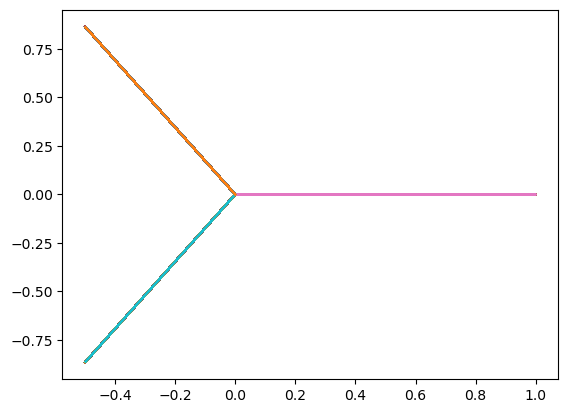

In [9]:

#cursor_pos = nwbfile.processing['behavior'].data_interfaces['Position'].spatial_series['cursor_pos']
go_cue_times = trial_times['go']
window = [0.2, 0.5]  # 200 ms before to 500 ms after go cue

cursor_pos_chunks = get_windowed_pos_chunk(kinematics, timestamps, go_cue_times, window)

for i, chunk in enumerate(cursor_pos_chunks):
    plt.plot(chunk[:,0],chunk[:,1])

In [10]:

neural_data, metadata = get_neural_data(nwbfile, go_cue_times, window)
m_neural_data, metadata = get_neural_data(m_nwbfile, go_cue_times, window)

In [11]:
print(np.shape(neural_data))
print(np.shape(m_neural_data))
len(m_neural_data[0])


(915, 256, 612)
(612, 18, 71)


18

(256, 612)
(256, 612)


(<Figure size 1200x800 with 2 Axes>,
 <Axes: title={'center': 'Neural Population Firing Rate'}, xlabel='Time Bin', ylabel='Unit Number'>)

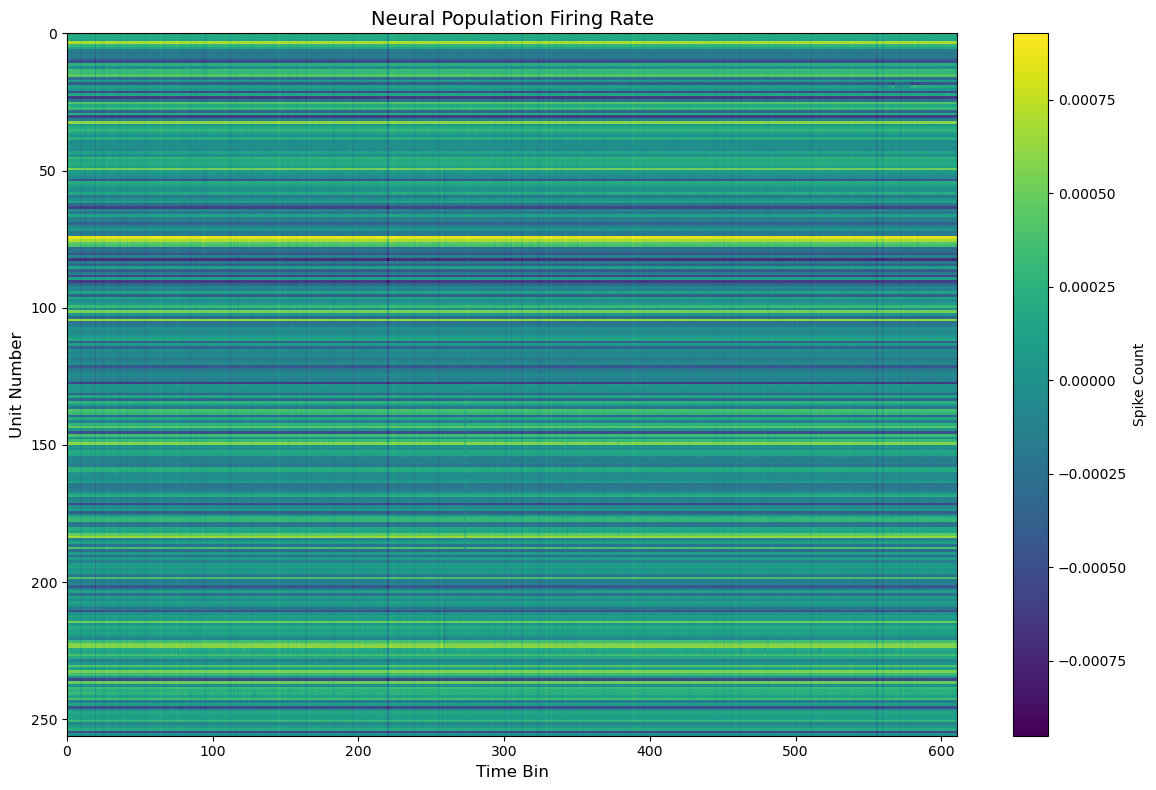

In [12]:
print(neural_data[0].shape)
avg_spike_rates = np.mean(neural_data,axis=0)
print(avg_spike_rates.shape)


plot_firing_rate_heatmap(avg_spike_rates, time_axis=None, bin_size=None,
                              figsize=(12, 8), cmap='viridis', 
                              vmin=None, vmax=None, title=None)


## Movement Detection

In [13]:
#nwbfile.processing['behavior'].data_interfaces['Velocity'].time_series

cursor_vel, timestamps, metadata = get_kinematics(m_nwbfile, kin_type="Velocity")


In [14]:



#cursor_vel = nwbfile.processing['behavior'].['Velocity'].time_series['cursor_vel']

# Usage
movement_times, movement_indices = get_movement_onset_times(
    cursor_vel, 
    timestamps,
    go_cue_times, 
    threshold=5.0,
    window=[-0.1, 1.0]
)

# Filter out trials with no movement detected
valid_trials = ~np.isnan(movement_times)
print(f"Movement detected in {valid_trials.sum()}/{len(go_cue_times)} trials")
print(f"First movement onset at: {movement_times[valid_trials][0]:.3f} seconds")



Movement detected in 398/612 trials
First movement onset at: 22.290 seconds


In [16]:
window = [0.0, 0.2]
movement_spike_data, metadata = get_neural_data(nwbfile, movement_times[valid_trials], window, bin_size=0.01)

window = [0.2, 0.0]
stationary_spike_data, metadata = get_neural_data(nwbfile, go_cue_times[valid_trials], window, bin_size=0.01)


AssertionError: window[0] must be less than window[1], got window=[0.2, 0.0]

In [17]:
window = [0.0, 0.2]
movement_spike_data, metadata = get_neural_data(nwbfile, go_cue_times, window, bin_size=0.01)

window = [-0.2, 0.0]
stationary_spike_data, metadata = get_neural_data(nwbfile, go_cue_times, window, bin_size=0.01)


In [19]:



data = movement_spike_data
move_category = np.ones(movement_spike_data.shape[2], dtype=int)  # All ones for movement


data = np.concatenate([data, stationary_spike_data], axis=2)
move_category = np.concatenate([move_category,
                           np.zeros(stationary_spike_data.shape[2], dtype=int)])  # All zeros for stationary


print(move_category.shape)
print(data.shape)



(1224,)
(610, 256, 1224)


In [22]:
# Train classifier

np.shape(data.T)

(1224, 256, 610)

In [ ]:
lda, results = train_lda_classifier(data.T, move_category)

# Visualize
plot_lda_results(results)

Data shape: (1224, 156160)
Labels shape: (1224,)
Class distribution: 0=612, 1=612
